In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import lag, corr
from pyspark.sql.window import Window

# Стартиране на SparkSession 
spark = (
    SparkSession.builder
    .appName("Test")
    .master("local[*]")
    .getOrCreate()
)

print("SparkSession стартиран успешно")
print("Spark версия:", spark.version)

SparkSession стартиран успешно
Spark версия: 4.0.1


In [8]:
# Дневни продажби на онлайн магазин
file_path = "sales_data.csv"

# Зареждане на CSV в DataFrame
df_sales = spark.read.csv(file_path, header=True, inferSchema=True)

# Показване на записите
df_sales.show()

+----------+------------+------------+-------------+
|       Day|Online_Sales|Coffee_Sales|Dessert_Sales|
+----------+------------+------------+-------------+
|2026-01-01|          52|          39|           37|
|2026-01-02|          49|          47|           49|
|2026-01-03|          43|          34|           35|
|2026-01-04|          44|          47|           50|
|2026-01-05|          34|          26|           28|
|2026-01-06|          29|          31|           30|
|2026-01-07|          32|          48|           44|
|2026-01-08|          28|          27|           26|
|2026-01-09|          21|          34|           36|
|2026-01-10|          22|          22|           26|
|2026-01-11|          15|          33|           36|
|2026-01-12|          12|          36|           39|
|2026-01-13|          11|          23|           18|
|2026-01-14|           0|          37|           40|
|2026-01-15|          -5|          27|           28|
|2026-01-16|          -5|          23|        

In [9]:
window = Window.orderBy("Day")

df_lagged = df_sales.withColumn(
    "sales_yesterday",
    lag("Online_Sales", 1).over(window)
)

df_lagged.show()

+----------+------------+------------+-------------+---------------+
|       Day|Online_Sales|Coffee_Sales|Dessert_Sales|sales_yesterday|
+----------+------------+------------+-------------+---------------+
|2026-01-01|          52|          39|           37|           NULL|
|2026-01-02|          49|          47|           49|             52|
|2026-01-03|          43|          34|           35|             49|
|2026-01-04|          44|          47|           50|             43|
|2026-01-05|          34|          26|           28|             44|
|2026-01-06|          29|          31|           30|             34|
|2026-01-07|          32|          48|           44|             29|
|2026-01-08|          28|          27|           26|             32|
|2026-01-09|          21|          34|           36|             28|
|2026-01-10|          22|          22|           26|             21|
|2026-01-11|          15|          33|           36|             22|
|2026-01-12|          12|         

In [10]:
df_lagged.select(
    corr("Coffee_sales", "Dessert_sales").alias("coffee_dessert_corr")
).show()


+-------------------+
|coffee_dessert_corr|
+-------------------+
| 0.9416094864257524|
+-------------------+



In [11]:
df_lagged.select(
    corr("Online_Sales", "sales_yesterday").alias("autocorrelation_lag1")
).show()


+--------------------+
|autocorrelation_lag1|
+--------------------+
|  0.9727527257077035|
+--------------------+



In [12]:
import matplotlib.pyplot as plt

pdf_sales = df_lagged.toPandas()


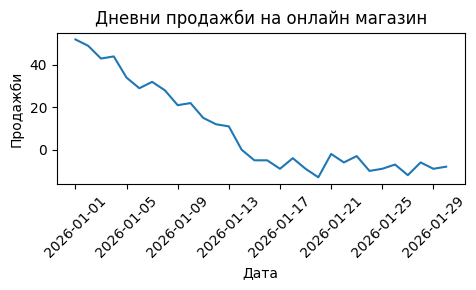

In [19]:
plt.figure(figsize=(5,3))
plt.plot(pdf_sales["Day"], pdf_sales["Online_Sales"])
plt.xticks(rotation=45)
plt.title("Дневни продажби на онлайн магазин")
plt.xlabel("Дата")
plt.ylabel("Продажби")
plt.tight_layout()
plt.show()


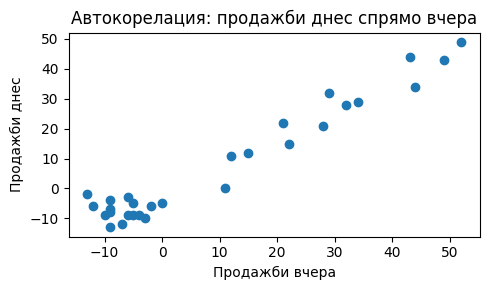

In [14]:
plt.figure(figsize=(5,3))
plt.scatter(pdf_sales["sales_yesterday"], pdf_sales["Online_Sales"])
plt.title("Автокорелация: продажби днес спрямо вчера")
plt.xlabel("Продажби вчера")
plt.ylabel("Продажби днес")
plt.tight_layout()
plt.show()


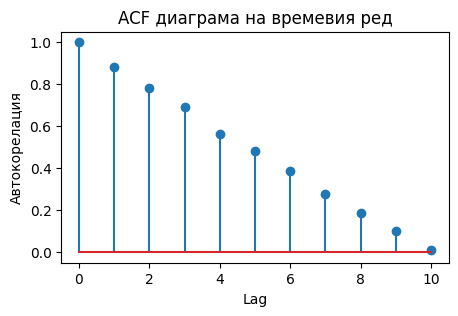

In [23]:
from statsmodels.tsa.stattools import acf

series = pdf_sales["Online_Sales"]
# Изчисляваме автокорелацията до 10 лагa
acf_values = acf(series, nlags=10)

plt.figure(figsize=(5,3))
plt.stem(range(len(acf_values)), acf_values)
plt.xlabel("Lag")
plt.ylabel("Автокорелация")
plt.title("ACF диаграма на времевия ред")
plt.show()


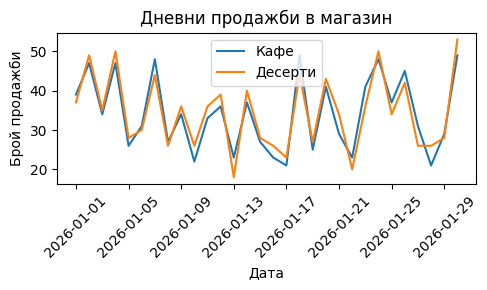

In [21]:
plt.figure(figsize=(5,3))
plt.plot(pdf_sales["Day"], pdf_sales["Coffee_Sales"], label="Кафе")
plt.plot(pdf_sales["Day"], pdf_sales["Dessert_Sales"], label="Десерти")
plt.xticks(rotation=45)
plt.title("Дневни продажби в магазин")
plt.xlabel("Дата")
plt.ylabel("Брой продажби")
plt.legend()
plt.tight_layout()
plt.show()


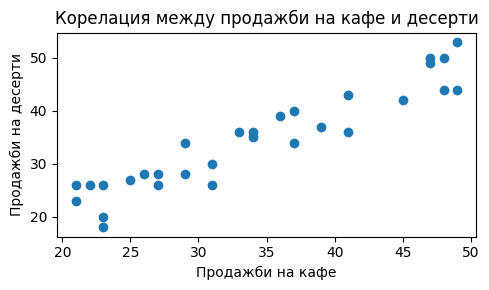

In [22]:
plt.figure(figsize=(5,3))
plt.scatter(pdf_sales["Coffee_Sales"], pdf_sales["Dessert_Sales"])
plt.title("Корелация между продажби на кафе и десерти")
plt.xlabel("Продажби на кафе")
plt.ylabel("Продажби на десерти")
plt.tight_layout()
plt.show()


In [3]:
import sys
!{sys.executable} -m pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.6 MB 27.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.6 MB 26.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 23.8 MB/s  0:00:00
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -----

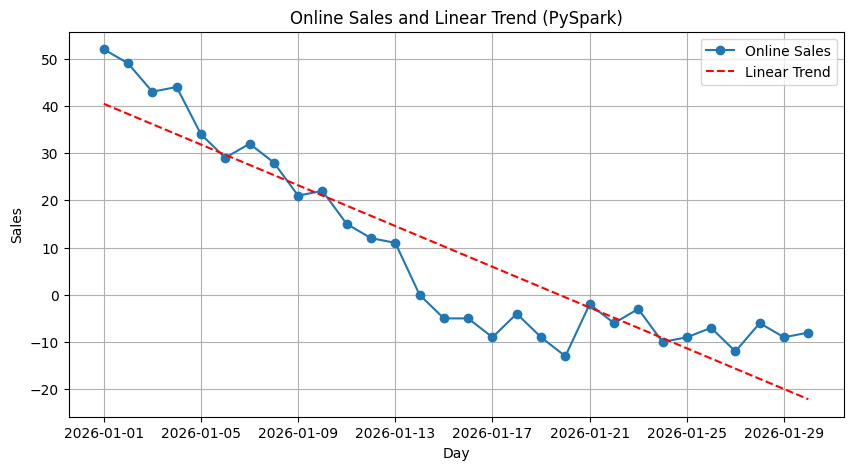

In [25]:
from pyspark.sql.functions import monotonically_increasing_id
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
import matplotlib.pyplot as plt

# --- 2. Четем данните от CSV ---
df = spark.read.csv("sales_data.csv", header=True, inferSchema=True)

# --- 3. Създаваме времеви индекс (t) ---
df = df.withColumn("t", monotonically_increasing_id())

# --- 4. Подготвяме данните за линейна регресия ---
assembler = VectorAssembler(inputCols=["t"], outputCol="features")
df_lr = assembler.transform(df).select("features", "Online_Sales")

# --- 5. Линейна регресия ---
lr = LinearRegression(featuresCol="features", labelCol="Online_Sales")
model = lr.fit(df_lr)

# --- 6. Прогноза на тренда ---
predictions = model.transform(df_lr)
pred_pd = predictions.select("Online_Sales", "prediction").toPandas()
df_index = df.select("Day").toPandas()

# --- 7. Визуализация ---
plt.figure(figsize=(10,5))
plt.plot(df_index["Day"], pred_pd["Online_Sales"], marker='o', label="Online Sales")
plt.plot(df_index["Day"], pred_pd["prediction"], color='red', linestyle='--', label="Linear Trend")
plt.title("Online Sales and Linear Trend (PySpark)")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.show()
